# VRT Cue-Centered Lag-CRP report

Report-style notebook for cue-centered lag-CRP contrasts in the VRT dataset.
Default response mask excludes cued responses (`cue_clips == 0`).


In [1]:
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.cue_centered_crp import plot_cue_centered_crp
from jaxcmr.helpers import find_project_root, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
run_tag = "VRT_CUE_CENTERED_CRP"
data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = ""
max_lag = 4
exclude_zero_lag = False
ylim = None
use_first_phase_only = True


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)

task = data["task"]
condition = data["condition"]
intervention = data["intervention"]
intentionality = data["intentionality"]

cue_mask = data["cue_clips"] > 0

def trial_mask(mask):
    return jnp.asarray(mask).reshape(-1)

first_phase_mask = trial_mask(((task == 1) & (intentionality == 1)) | ((task == 2) & (intentionality == 2)))
phase_label = "First Phase" if use_first_phase_only else "All Phases"


def phase_mask(mask):
    base = trial_mask(mask)
    return base & first_phase_mask if use_first_phase_only else base


def summarize_masks(labels, masks):
    for label, mask in zip(labels, masks):
        n_trials = int(jnp.sum(mask))
        n_subjects = int(jnp.unique(data["subject"][mask]).size)
        print(f"{label}: trials={n_trials}, subjects={n_subjects}")


def plot_contrast(masks, labels, contrast_name, axis=None, suffix=None):
    plot_cue_centered_crp(
        datasets=[data] * len(masks),
        trial_masks=masks,
        should_tabulate=[cue_mask] * len(masks),
        max_lag=max_lag,
        labels=labels,
        contrast_name=contrast_name,
        axis=axis,
        exclude_zero_lag=exclude_zero_lag,
    )
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    if axis is None:
        save_figure(figure_dir, figure_str, suffix=suffix or contrast_name)


## Q1. Is Cue-Centered Lag-CRP Different Between Involuntary And Voluntary Tasks?


Involuntary: trials=240, subjects=240
Voluntary: trials=240, subjects=240


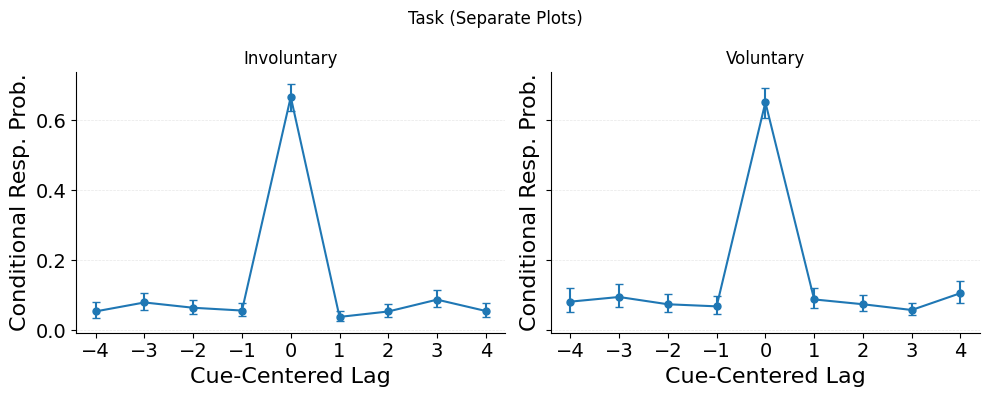

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Involuntary")
plot_contrast([masks[1]], [labels[1]], contrast_name=None, axis=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("Task (Separate Plots)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_separate")


## Q2. What If We Only Look At The First Recall Trial After Each Study Phase?

Use `use_first_phase_only` (in the parameters cell) to toggle whether analyses after Q2 are restricted to first-phase trials. When True:
- intentionality == 1 (Involuntary-First) → task == 1 (Involuntary)
- intentionality == 2 (Voluntary-First) → task == 2 (Voluntary)

When False, analyses include both phases.


Matched-First: trials=240, subjects=240
Mismatched-First: trials=240, subjects=240


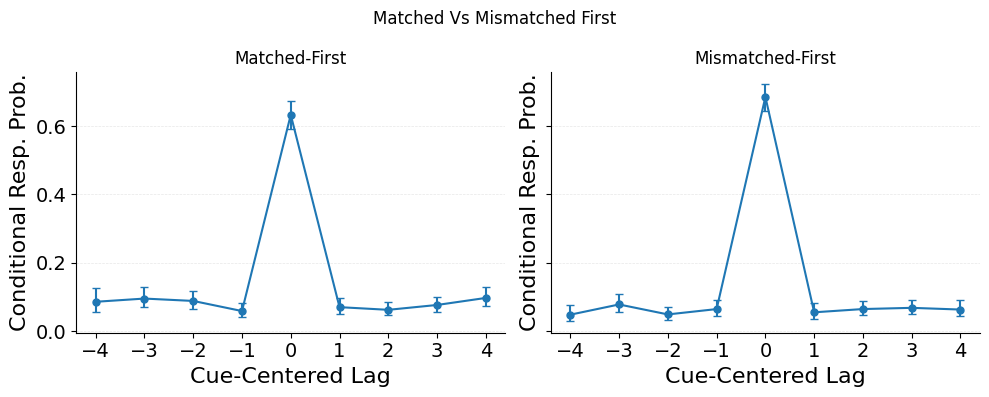

Voluntary · Involuntary-First: trials=120, subjects=120
Voluntary · Voluntary-First: trials=120, subjects=120


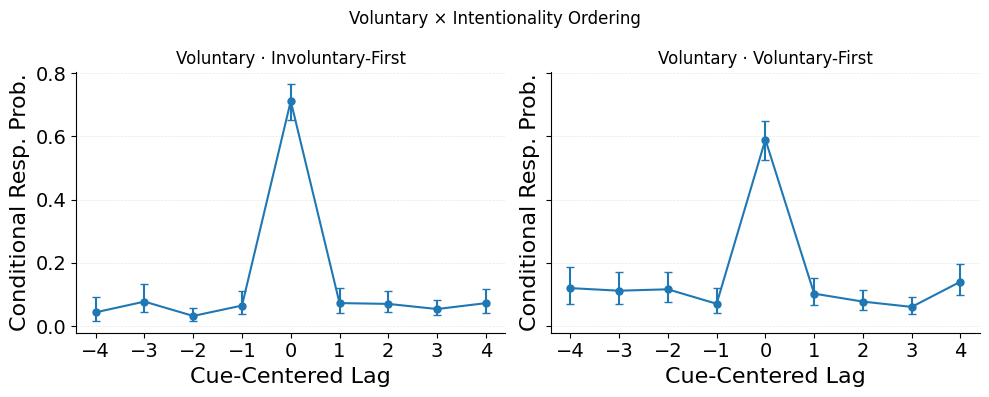

Involuntary · Involuntary-First: trials=120, subjects=120
Involuntary · Voluntary-First: trials=120, subjects=120


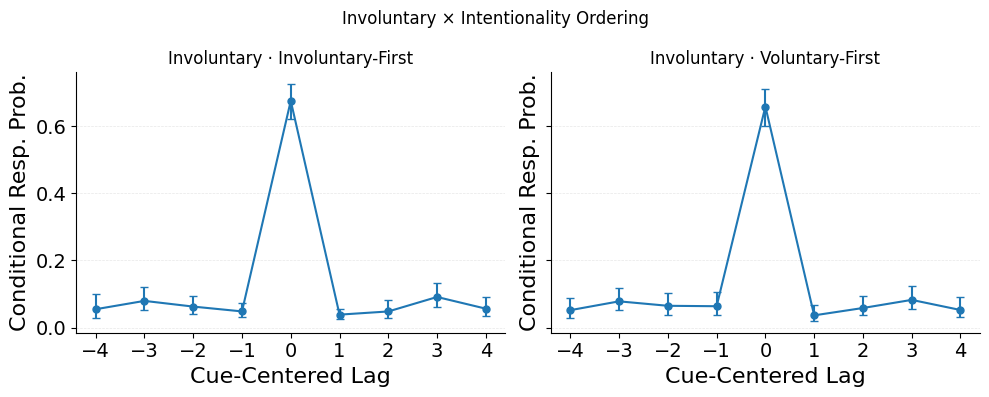

In [5]:
# Q2 Add-On: One-IV-At-A-Time Comparisons

# Matched-First vs Mismatched-First
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_matched = trial_mask(((task == 1) & (intentionality == 1)) | ((task == 2) & (intentionality == 2)))
mask_mismatched = trial_mask(((task == 1) & (intentionality == 2)) | ((task == 2) & (intentionality == 1)))

labels = ["Matched-First", "Mismatched-First"]
masks = [mask_matched, mask_mismatched]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Matched-First")
plot_contrast([masks[1]], [labels[1]], contrast_name=None, axis=axes[1])
axes[1].set_title("Mismatched-First")

fig.suptitle("Matched Vs Mismatched First")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intentionality_matched_mismatched")

# Voluntary Only: Intentionality Ordering
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_voluntary_involuntary_first = trial_mask((task == 2) & (intentionality == 1))
mask_voluntary_voluntary_first = trial_mask((task == 2) & (intentionality == 2))

labels = ["Voluntary · Involuntary-First", "Voluntary · Voluntary-First"]
masks = [mask_voluntary_involuntary_first, mask_voluntary_voluntary_first]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Voluntary · Involuntary-First")
plot_contrast([masks[1]], [labels[1]], contrast_name=None, axis=axes[1])
axes[1].set_title("Voluntary · Voluntary-First")

fig.suptitle("Voluntary × Intentionality Ordering")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intentionality_voluntary")

# Involuntary Only: Intentionality Ordering
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_involuntary_involuntary_first = trial_mask((task == 1) & (intentionality == 1))
mask_involuntary_voluntary_first = trial_mask((task == 1) & (intentionality == 2))

labels = ["Involuntary · Involuntary-First", "Involuntary · Voluntary-First"]
masks = [mask_involuntary_involuntary_first, mask_involuntary_voluntary_first]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Involuntary · Involuntary-First")
plot_contrast([masks[1]], [labels[1]], contrast_name=None, axis=axes[1])
axes[1].set_title("Involuntary · Voluntary-First")

fig.suptitle("Involuntary × Intentionality Ordering")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intentionality_involuntary")


Involuntary · Involuntary-First: trials=120, subjects=120
Voluntary · Voluntary-First: trials=120, subjects=120


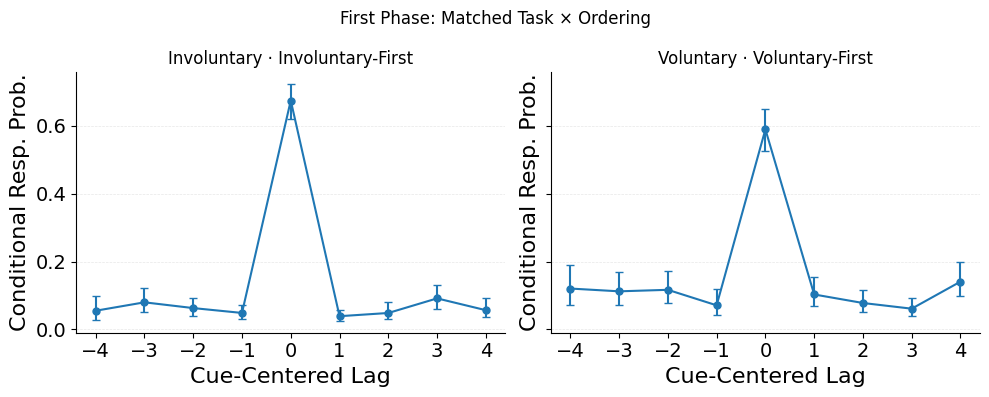

In [6]:
# Q2 Add-On: Matched First-Phase Tasks (1×2 Panels)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_involuntary_involuntary_first = trial_mask((task == 1) & (intentionality == 1))
mask_voluntary_voluntary_first = trial_mask((task == 2) & (intentionality == 2))

labels = ["Involuntary · Involuntary-First", "Voluntary · Voluntary-First"]
masks = [mask_involuntary_involuntary_first, mask_voluntary_voluntary_first]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Involuntary · Involuntary-First")
plot_contrast([masks[1]], [labels[1]], contrast_name=None, axis=axes[1])
axes[1].set_title("Voluntary · Voluntary-First")

fig.suptitle("First Phase: Matched Task × Ordering")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intentionality_first_phase_panels")


Involuntary · Involuntary-First: trials=120, subjects=120
Voluntary · Voluntary-First: trials=120, subjects=120


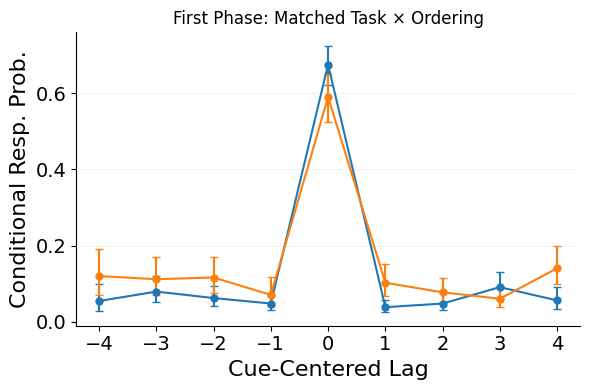

In [10]:
# Q2 Add-On: Matched First-Phase Tasks (Overlay)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

mask_involuntary_involuntary_first = trial_mask((task == 1) & (intentionality == 1))
mask_voluntary_voluntary_first = trial_mask((task == 2) & (intentionality == 2))

labels = ["Involuntary · Involuntary-First", "Voluntary · Voluntary-First"]
masks = [mask_involuntary_involuntary_first, mask_voluntary_voluntary_first]
summarize_masks(labels, masks)
plot_contrast(masks, labels, contrast_name=None, axis=ax)
ax.set_title("First Phase: Matched Task × Ordering")

plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intentionality_first_phase_overlay")


Negative Film · Involuntary: n_subjects=60, mean=54.05%
Negative Film · Voluntary: n_subjects=57, mean=47.22%
Neutral Film · Involuntary: n_subjects=58, mean=81.41%
Neutral Film · Voluntary: n_subjects=59, mean=70.36%


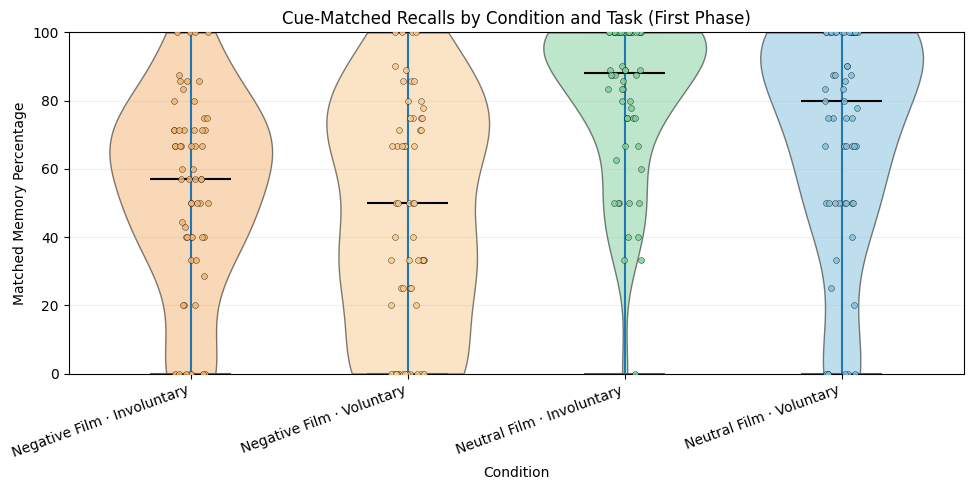

In [15]:
# Q2 Add-On: Cue-Matched Recall Boxplot (Condition × Task)

import numpy as np
from jax import jit
from jaxcmr.analyses.cue_centered_crp import cue_centered_crp
from jaxcmr.helpers import apply_by_subject

# Compute subject-level cue-matched recall rate (cue-centered lag = 0).
def subject_zero_lag_percent(mask):
    # Restrict this comparison to first-phase trials only.
    masked_trials = mask & first_phase_mask
    data_with_mask = {**data, "_should_tabulate": cue_mask}
    subject_curves = apply_by_subject(
        data_with_mask,
        masked_trials,
        jit(cue_centered_crp, static_argnames=("size",)),
        size=3,
    )
    # The center index corresponds to lag 0 in the cue-centered CRP vector.
    lag_range = int(data["pres_itemnos"].shape[1]) - 1
    zero_lag = np.array([np.asarray(curve)[lag_range] for curve in subject_curves], dtype=float)
    return zero_lag * 100.0

# Four groups: condition (negative vs neutral) crossed with task.
configs = [
    (trial_mask((condition == 1) & (task == 1)), "Negative Film · Involuntary", "#f2b36f"),
    (trial_mask((condition == 1) & (task == 2)), "Negative Film · Voluntary", "#f8c98d"),
    (trial_mask((condition == 2) & (task == 1)), "Neutral Film · Involuntary", "#7ccf9a"),
    (trial_mask((condition == 2) & (task == 2)), "Neutral Film · Voluntary", "#7fbfdd"),
]

group_data = []
labels = []
colors = []
# Collect one cue-matched percentage per subject for each group.
for mask, label, color in configs:
    values = subject_zero_lag_percent(mask)
    values = values[np.isfinite(values)]
    group_data.append(values)
    labels.append(label)
    colors.append(color)
    mean_value = float(np.mean(values)) if len(values) else float("nan")
    print(f"{label}: n_subjects={len(values)}, mean={mean_value:.2f}%")

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Draw a violin for each group and overlay jittered points for subjects.
positions = np.arange(1, len(group_data) + 1)
violin = ax.violinplot(group_data, positions=positions, widths=0.75, showmedians=True)
for body, color in zip(violin["bodies"], colors):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.5)
if "cmedians" in violin:
    violin["cmedians"].set_color("black")
    violin["cmedians"].set_linewidth(1.5)

rng = np.random.default_rng(7)
for pos, values, color in zip(positions, group_data, colors):
    jitter = rng.uniform(-0.08, 0.08, size=len(values))
    x_values = np.full(len(values), pos, dtype=float) + jitter
    ax.scatter(
        x_values,
        values,
        s=18,
        color=color,
        edgecolors="black",
        linewidths=0.3,
        alpha=0.85,
        zorder=3,
    )

ax.set_title("Cue-Matched Recalls by Condition and Task (First Phase)")
ax.set_ylabel("Matched Memory Percentage")
ax.set_xlabel("Condition")
ax.set_ylim(0, 100)
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="cue_matched_violin_condition_task")


## Q3. Task × Condition (Emotional Vs Neutral)


Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


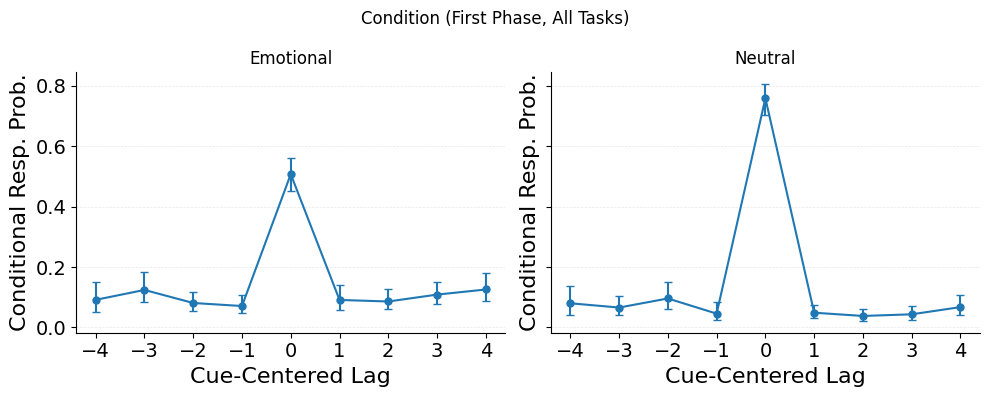

Emotional: trials=60, subjects=60
Neutral: trials=60, subjects=60


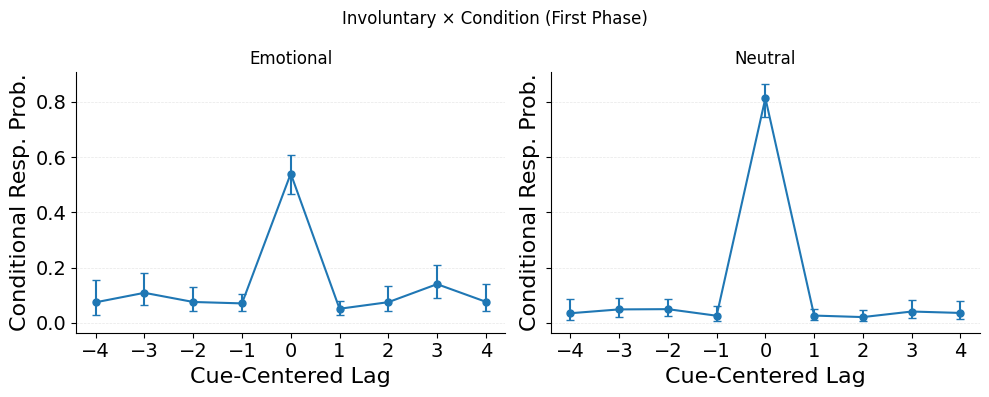

Emotional: trials=60, subjects=60
Neutral: trials=60, subjects=60


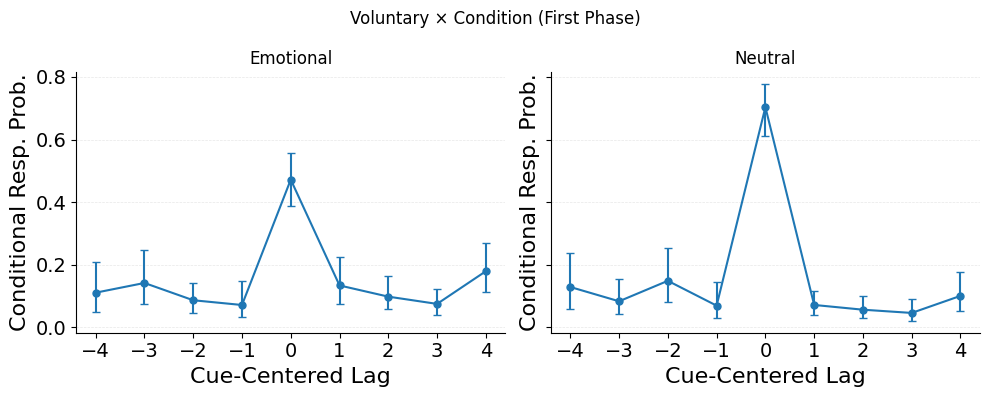

In [7]:
# Q3 Add-On: Condition (All Tasks)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_first_phase = first_phase_mask if use_first_phase_only else trial_mask(jnp.ones_like(task, dtype=bool))

mask_emotional = mask_first_phase & trial_mask(condition == 1)
labels = ["Emotional"]
masks = [mask_emotional]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Emotional")

mask_neutral = mask_first_phase & trial_mask(condition == 2)
labels = ["Neutral"]
masks = [mask_neutral]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Neutral")

fig.suptitle(f"Condition ({phase_label}, All Tasks)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="condition_all_tasks")


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_involuntary = phase_mask(task == 1)

mask_emotional = mask_involuntary & trial_mask(condition == 1)
labels = ["Emotional"]
masks = [mask_emotional]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Emotional")

mask_neutral = mask_involuntary & trial_mask(condition == 2)
labels = ["Neutral"]
masks = [mask_neutral]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Neutral")

fig.suptitle(f"Involuntary × Condition ({phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_condition_involuntary")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_voluntary = phase_mask(task == 2)

mask_emotional = mask_voluntary & trial_mask(condition == 1)
labels = ["Emotional"]
masks = [mask_emotional]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Emotional")

mask_neutral = mask_voluntary & trial_mask(condition == 2)
labels = ["Neutral"]
masks = [mask_neutral]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Neutral")

fig.suptitle(f"Voluntary × Condition ({phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_condition_voluntary")


## Q4. Task × Intervention (Podcast Vs Tetris)


Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


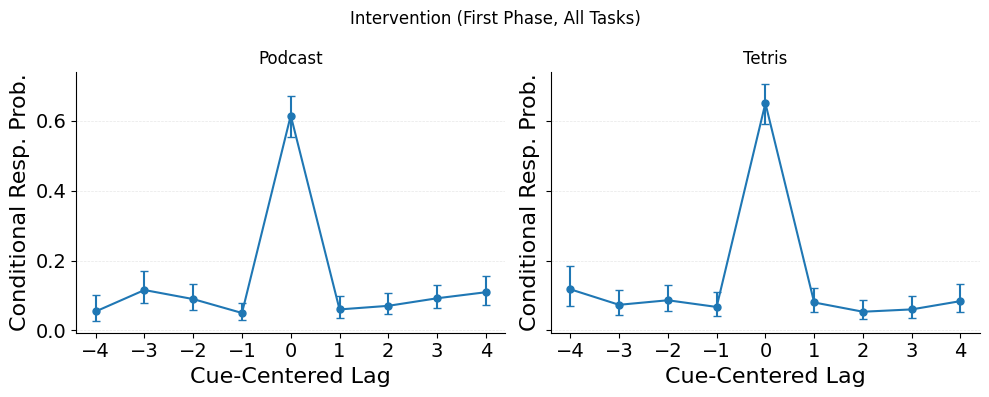

Podcast: trials=60, subjects=60
Tetris: trials=60, subjects=60


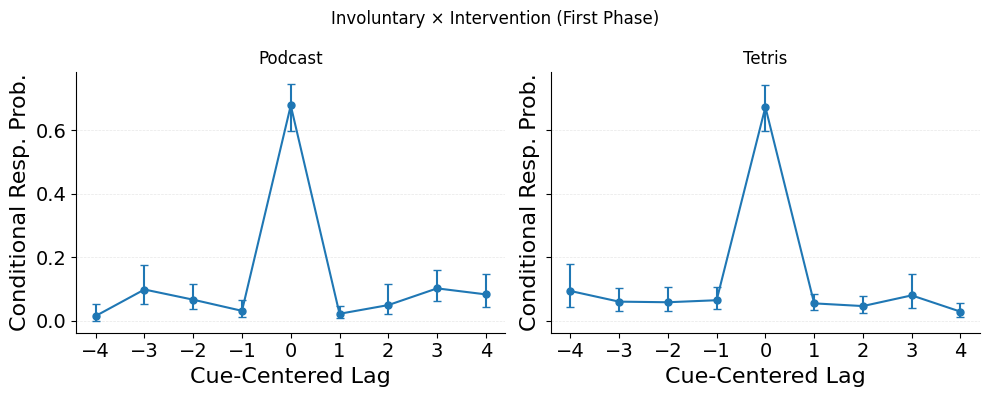

Podcast: trials=60, subjects=60
Tetris: trials=60, subjects=60


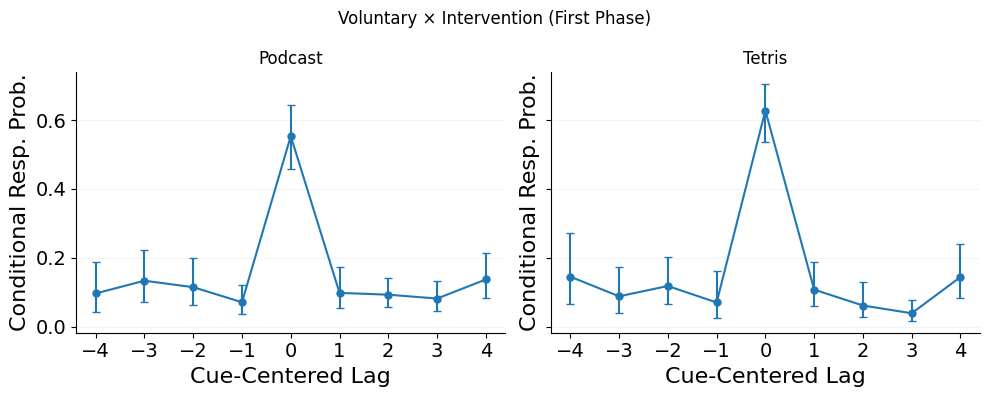

In [8]:
# Q4 Add-On: Intervention (All Tasks)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_first_phase = first_phase_mask if use_first_phase_only else trial_mask(jnp.ones_like(task, dtype=bool))

mask_podcast = mask_first_phase & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_first_phase & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Intervention ({phase_label}, All Tasks)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_all_tasks")


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_involuntary = phase_mask(task == 1)

mask_podcast = mask_involuntary & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_involuntary & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Involuntary × Intervention ({phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intervention_involuntary")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_voluntary = phase_mask(task == 2)

mask_podcast = mask_voluntary & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_voluntary & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Voluntary × Intervention ({phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="task_intervention_voluntary")


## Q5. Task × Intervention × Condition


Podcast: trials=60, subjects=60
Tetris: trials=60, subjects=60


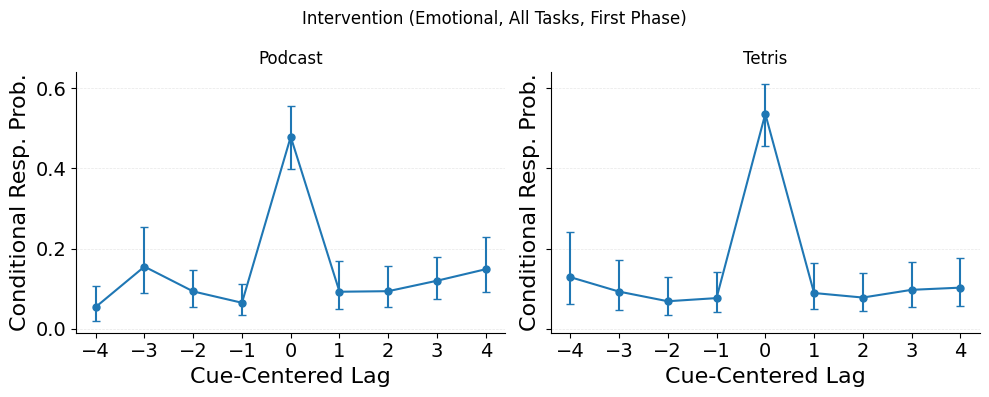

Podcast: trials=60, subjects=60
Tetris: trials=60, subjects=60


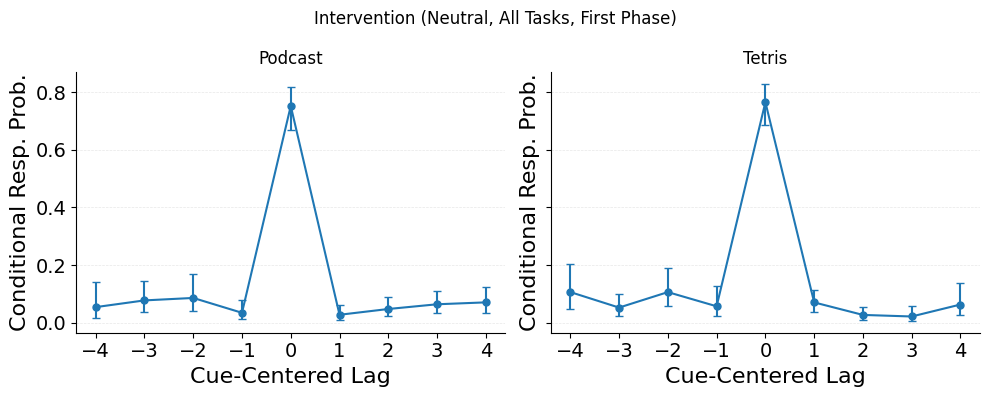

Podcast: trials=30, subjects=30
Tetris: trials=30, subjects=30


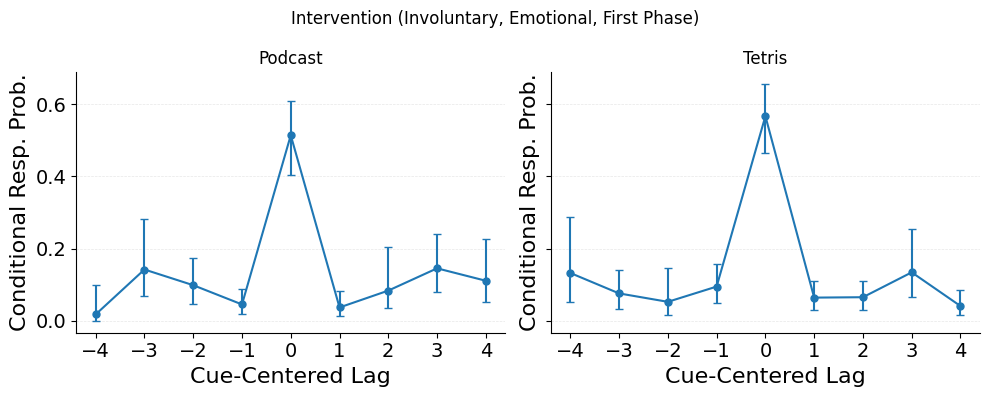

Podcast: trials=30, subjects=30
Tetris: trials=30, subjects=30


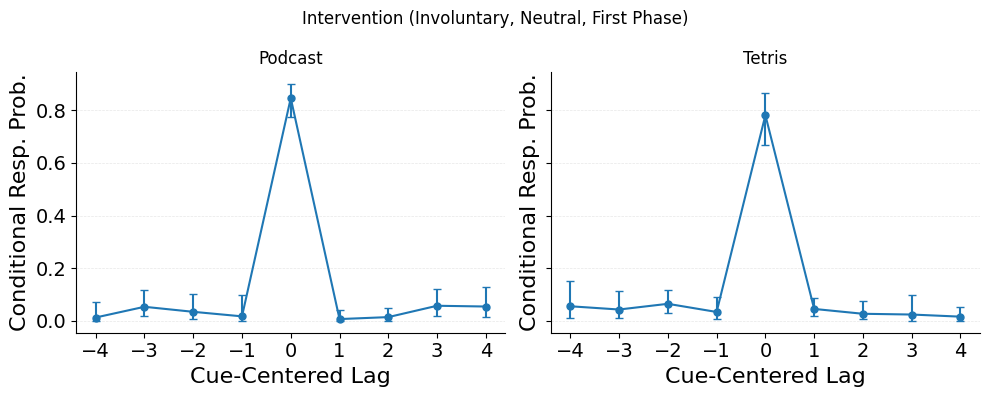

Podcast: trials=30, subjects=30
Tetris: trials=30, subjects=30


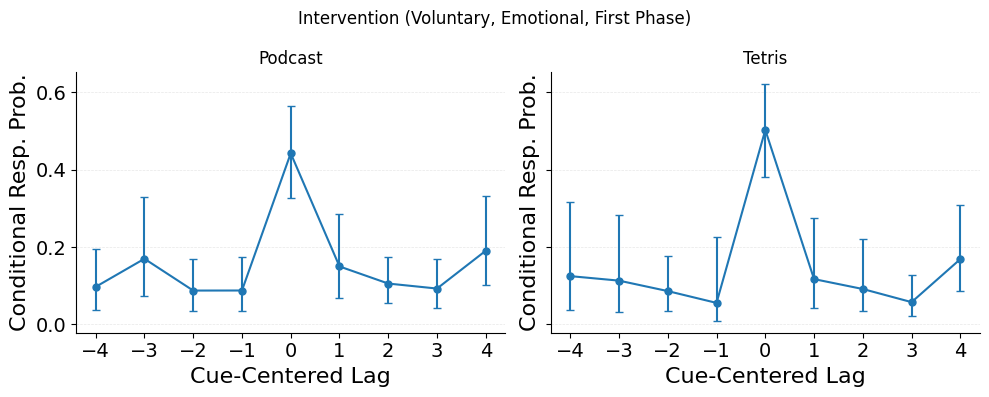

Podcast: trials=30, subjects=30
Tetris: trials=30, subjects=30


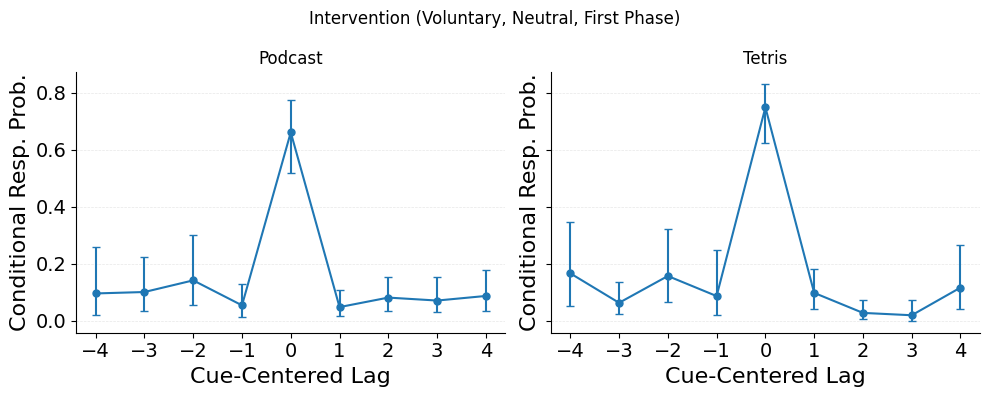

In [9]:
# Q5: Intervention Effects By Condition And Task (1×2 Panels)

# All Tasks: Emotional
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_all = phase_mask(jnp.ones_like(task, dtype=bool))
mask_emotional = mask_all & trial_mask(condition == 1)

mask_podcast = mask_emotional & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_emotional & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Intervention (Emotional, All Tasks, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_emotional_all")

# All Tasks: Neutral
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_neutral = mask_all & trial_mask(condition == 2)

mask_podcast = mask_neutral & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_neutral & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Intervention (Neutral, All Tasks, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_neutral_all")

# Involuntary: Emotional
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_involuntary = phase_mask(task == 1)
mask_emotional = mask_involuntary & trial_mask(condition == 1)

mask_podcast = mask_emotional & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_emotional & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Intervention (Involuntary, Emotional, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_involuntary_emotional")

# Involuntary: Neutral
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_neutral = mask_involuntary & trial_mask(condition == 2)

mask_podcast = mask_neutral & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_neutral & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Intervention (Involuntary, Neutral, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_involuntary_neutral")

# Voluntary: Emotional
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_voluntary = phase_mask(task == 2)
mask_emotional = mask_voluntary & trial_mask(condition == 1)

mask_podcast = mask_emotional & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_emotional & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Intervention (Voluntary, Emotional, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_voluntary_emotional")

# Voluntary: Neutral
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_neutral = mask_voluntary & trial_mask(condition == 2)

mask_podcast = mask_neutral & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_neutral & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Intervention (Voluntary, Neutral, {phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="intervention_voluntary_neutral")
